In [1]:
import os, yaml, sys
import numpy as np
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt

ENV = os.getenv("MY_ENV", "dev")
with open("../../../temporal_context/config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
sys.path.append(paths["useful_stuff_path"])
from general_utils.utils import BrainAreas, dRSA, load_img_natraster, print_wise, TimeSeries


In [2]:
from dataclasses import dataclass, field

@dataclass
class Cfg:
    monkey_name: str = 'paul' 
    date: str = '230204'
    brain_area: str = 'AIT'
    new_fs: int = 100 # Hz
    RDM_metric_A: str = 'cosine'
    RDM_metric_B: str = 'correlation'
    k: int = 1
cfg = Cfg()

In [3]:
raster = load_img_natraster(paths, cfg.monkey_name, cfg.date, new_fs=cfg.new_fs)

In [41]:
ba_raster = TimeSeries(raster.get_array()[:50, :, :], fs=cfg.new_fs)

In [39]:
cfg.model_name = 'vit_l_16'; cfg.img_size = 384; cfg.pooling = 'mean'; layer_name = 'blocks.16.mlp.fc2'

feats_filename = f"{paths['livingstone_lab']}/tiziano/models/{cfg.monkey_name}_{cfg.date}_{cfg.model_name}_{cfg.img_size}_{layer_name}_features_{cfg.pooling}pool.npz"
features = np.load(feats_filename)["arr_0"]

In [6]:
from sklearn.linear_model import LinearRegression, RidgeCV, MultiTaskLassoCV, MultiTaskElasticNetCV
from sklearn.model_selection import KFold, LeaveOneOut
from useful_stuff.general_utils.regression import IdentitySplit

def choose_regression_type(regression_type, alphas=np.logspace(-6, 3, 10), l1_ratio=[0.1, 0.5, 0.9], **kwargs):
    if regression_type == 'lr': 
        regression_obj = LinearRegression()
    elif regression_type == 'ridge': 
        regression_obj = RidgeCV(alphas=alphas)
    elif regression_type == 'lasso': 
        regression_obj = MultiTaskLassoCV(alphas=alphas, max_iter=10000)
    elif regression_type == 'en': 
        regression_obj = MultiTaskElasticNetCV(alphas=alphas, max_iter=10000, l1_ratio=l1_ratio)
    else:
        raise ValueError("regression_type must be 'lr', 'ridge', 'lasso', 'en'")
    return regression_obj
# EOF

def choose_CV_type(cv_type, n_splits=5, shuffle=True):
    if cv_type == 'same':
        CV = IdentitySplit(shuffle=shuffle)
    elif cv_type == 'loo': # leave one-out
        CV = LeaveOneOut()
    elif cv_type == 'kf': # leave one-out
        CV = KFold(n_splits=n_splits, shuffle=shuffle)
    else:
        raise ValueError("cv_type must be 'same', 'loo', 'kf'")
    # end if cv_type == 'same':
    return CV
# EOF

def evaluate_prediction_corr(Y_test, y_hat):
    if Y_test.shape[1]==1:
        raise ValueError("You can't run correlation with just 1 feature")
    # end if Y_test.shape[1]==1:
    corr_vals = np.array([np.corrcoef(y_hat[i, :], Y_test[i, :])[0, 1] for i in range(Y_test.shape[0])])
    if np.any(np.isnan(corr_vals)):
        Warning("We have NaNs in the correlation values")
    # end if np.any(np.isnan(corr_vals)):
    avg_corr = np.nanmean(corr_vals)
    return avg_corr
# EOF


In [7]:
from sklearn.metrics import r2_score
class linear_encoding:
    def __init__(self, regression_type: str, cv_type: str, alphas: np.ndarray=np.logspace(-6, 3, 10), score_type: str='r2', n_splits: int=5, shuffle: bool=True, **kwargs):
        self.regression_type = regression_type 
        self.alphas = alphas
        self.regression_obj = choose_regression_type(self.regression_type, alphas=self.alphas, **kwargs)
        self.cv_type = cv_type
        self.cv_obj = choose_CV_type(cv_type, n_splits=n_splits, shuffle=shuffle)
        self.additional_args = kwargs
        self.score_type = score_type
    # EOF
    # --- GETTERS ---
    def get_regression_type(self):
        return self.regression_type
    # EOF
    def get_regression_obj(self):
        return self.regression_obj
    # EOF
    def get_alphas(self):
        return self.alphas
    # EOF
    def get_cv_type(self):
        return self.cv_type
    # EOF
    def get_cv_obj(self):
        return self.cv_obj
    # EOF
    def get_weights(self):
        return self.regression_obj.coef_
    # EOF
    def get_intercept(self):
        return self.regression_obj.intercept_
    # EOF
    def get_score_vals(self):
        return self.score_vals
    # EOF
    def get_score_type(self):
        return self.score_type
    # EOF
    # --- SETTERS ---
    def set_regression_type(self, regression_type: str, alphas=None, **kwargs):
        self.regression_type = regression_type
        if alphas is not None:
            self.alphas = alphas
        # end if alphas is not None:
        if kwargs is not None:
            self.additional_args = kwargs
        # end if kwargs is not None:
        self.regression_obj = choose_regression_type(self.regression_type, alphas=self.alphas, **self.additional_args)
    # EOF
    def set_regression_obj(self):
        raise AttributeError("Pass through set_regression_type to set a new regression object")
    # EOF
    def set_alphas(self):
        raise AttributeError("Pass through set_regression_type to set a new set of alphas")
    # EOF
    def set_cv_type(self, cv_type, n_splits=5, shuffle=True):
        self.cv_type = cv_type
        self.cv_obj = choose_CV_type(cv_type, n_splits=n_splits, shuffle=shuffle)
    # EOF
    def set_cv_obj(self):
        raise AttributeError("Pass through set_cv_type to set a new cv_obj")
    # EOF
    # --- OTHER METHODS ---
    def fit(self, X_train: np.ndarray, Y_train: np.ndarray, transpose=True):
        if transpose:
            X_train = np.ascontiguousarray(X_train.T)
            Y_train = np.ascontiguousarray(Y_train.T)
        # end if transpose:
        self.regression_obj.fit(X_train, Y_train)
        return self.get_weights(), self.get_intercept()
    # EOF
    def predict(self, X: np.ndarray, transpose=True, transpose_output=True):
        if transpose:
            X = np.ascontiguousarray(X.T)
        # end if transpose:
        y_hat = self.regression_obj.predict(X)
        if transpose_output:
            y_hat = np.ascontiguousarray(y_hat.T)
        # if transpose_output:
        return y_hat
    # EOF
    def score(self, X_test: np.ndarray, Y_test: np.ndarray, transpose=True):
        if transpose:
            X_test = np.ascontiguousarray(X_test.T)
            Y_test = np.ascontiguousarray(Y_test.T)
        # end if transpose:
        y_hat = self.predict(X_test, transpose=False, transpose_output=False)
        if self.score_type=='r2':
            score = r2_score(Y_test, y_hat, multioutput="raw_values")
        elif self.score_type=="corr": 
            score = evaluate_prediction_corr(Y_test, y_hat)
        # end if score_type=='r2':
        self.score_vals = score
        return score
    # EOF
# EOC


In [75]:
import matplotlib.pyplot as plt
import numpy as np

model = linear_encoding('ridge', 'kf', score_type="r2")

cmap = plt.cm.viridis
t_pts = 30
colors = cmap(np.linspace(0, 1, ba_raster.get_array().shape[0]))
time_score_r2 = []
for i in range(t_pts):
    X = features
    Y = ba_raster[i]
    neu, pts = Y.shape
    score = None
    counter = 0
    for train_idx, test_idx in model.get_cv_obj().split(X):
        X_train, Y_train = X[:, train_idx], Y[:, train_idx]
        X_test, Y_test = X[:, test_idx], Y[:, test_idx]
        model.fit(X_train, Y_train)
        y_pred = model.predict(X_test)
        counter+=1
        if score is None:
            score = model.score(X_test, Y_test)
        else:
            score += model.score(X_test, Y_test)
    time_score_r2.append(score/counter)


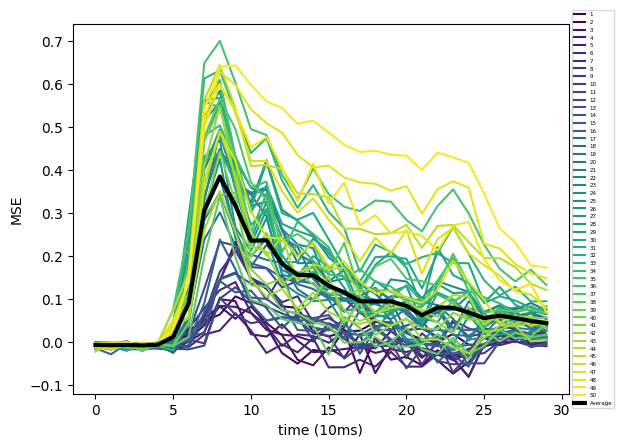

<Figure size 640x480 with 0 Axes>

In [80]:
if type(time_score_r2)== list: time_score_r2 = np.stack(time_score_r2, axis=1)
for i, c in enumerate(colors):
    plt.plot(time_score_r2[i,:], color=c, label=f"{i+1}")
# plt.plot(time_score)
plt.plot(np.mean(time_score_r2, axis=0), linewidth="3", color="k", label="Average")
plt.legend(fontsize=4, loc="center left", bbox_to_anchor=(1, 0.5))
plt.ylabel("MSE")
plt.xlabel("time (10ms)")
plt.show()
plt.tight_layout()

In [82]:
import matplotlib.pyplot as plt
import numpy as np

model = linear_encoding('ridge', 'kf', score_type="corr")

cmap = plt.cm.viridis
t_pts = 30
colors = cmap(np.linspace(0, 1, ba_raster.get_array().shape[0]))
time_score_corr = []
for i in range(t_pts):
    X = features
    Y = ba_raster[i]
    neu, pts = Y.shape
    score = None
    counter = 0
    for train_idx, test_idx in model.get_cv_obj().split(X):
        X_train, Y_train = X[:, train_idx], Y[:, train_idx]
        X_test, Y_test = X[:, test_idx], Y[:, test_idx]
        model.fit(X_train, Y_train)
        y_pred = model.predict(X_test)
        counter+=1
        if score is None:
            score = model.score(X_test, Y_test)
        else:
            score += model.score(X_test, Y_test)
    time_score_corr.append(score/counter)


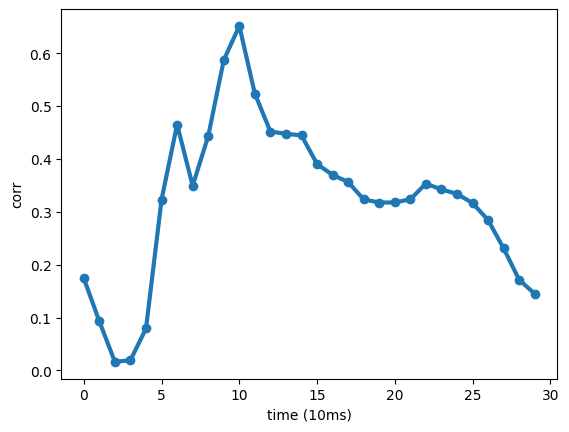

<Figure size 640x480 with 0 Axes>

In [85]:
plt.plot(time_score_corr, "-o", linewidth=3)
# plt.legend(fontsize=4, loc="center left", bbox_to_anchor=(1, 0.5))
plt.ylabel("corr")
plt.xlabel("time (10ms)")
plt.show()
plt.tight_layout()

### load brain data and model

keep only the first 1000 images to speed up the analyses

In [10]:
lr_list = static_lagged_linear_regression(feats, ba_raster.get_array(), regression_type='lr', alphas=np.logspace(-6, 3, 10), cv_type='kf')

In [12]:
try_raster = TimeSeries(ba_raster.get_array()[:,:,:1000], raster.get_fs()) 
feats = features[:,:1000] 

Text(0.5, 1.0, 'normal linear regression')

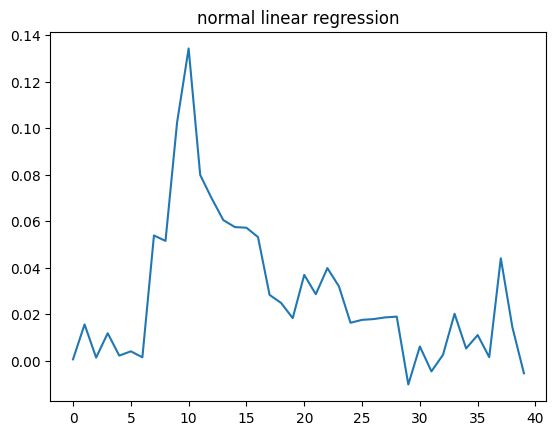

In [12]:
plt.plot(lr_list)
plt.title("normal linear regression")

In [27]:
def static_lagged_linear_regression(x, y, regression_type='lr', alphas=np.logspace(-6, 3, 10), cv_type='same', n_splits=5, shuffle=True):
    lr_list = []
    x_shifted_tot = x.T
    for tau in range(y.shape[1]):
        y_shifted_tot = y[:,tau,:].T
        CV = choose_CV_type(cv_type, n_splits=n_splits, shuffle=shuffle)
        curr_lr = []
        for train_idx, test_idx in CV.split(x_shifted_tot):
            train_x, train_y = x_shifted_tot[train_idx, :], y_shifted_tot[train_idx, :]
            test_x, test_y = x_shifted_tot[test_idx, :], y_shifted_tot[test_idx, :]
            regression_obj = choose_regression_type(regression_type=regression_type, alphas=alphas)
            regression_obj = regression_obj.fit(train_x, train_y)
            avg_corr = evaluate_prediction(test_x, test_y, regression_obj)
            curr_lr.append(avg_corr)
        # end for train_idx, test_idx in CV.split(x_shifted_tot):
        lr_list.append(np.nanmean(curr_lr))  #x_t_shifted_tot, y_t_shifted_tot))
    # end for L in range(-max_lag, max_lag):    
    return lr_list
# EOF


In [28]:
lr_list = static_lagged_linear_regression(feats, ba_raster.get_array(), regression_type='en', alphas=np.logspace(-6, 3, 10), cv_type='kf')

/Users/tizianocausin/Desktop/virtual_envs/temporal_context/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:673: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.714e+01, tolerance: 4.070e-02
  model = cd_fast.enet_coordinate_descent_multi_task(


KeyboardInterrupt: 

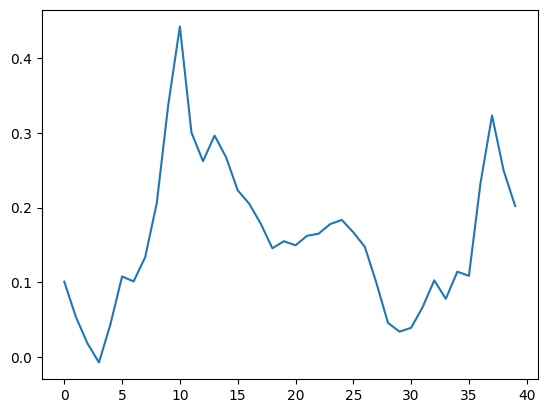

In [ ]:
plt.plot(lr_list)